# Autoencoder on MNIST: Feature Extraction and Analysis

**MTH767 Project 2026**

This notebook implements three types of autoencoders trained on the MNIST dataset:
1. **Fully-Connected Autoencoder** (baseline)
2. **Convolutional Autoencoder** (improved reconstruction)
3. **Variational Autoencoder (VAE)** (structured latent space)

We analyze the extracted features through reconstruction quality, latent space visualization, and interpolation experiments.

## 1. Setup and Data Loading

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

#set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

#device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
#data loading
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Training samples: {len(train_dataset)}')
print(f'Test samples: {len(test_dataset)}')
print(f'Image shape: {train_dataset[0][0].shape}')

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.09MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.9MB/s]

Training samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])


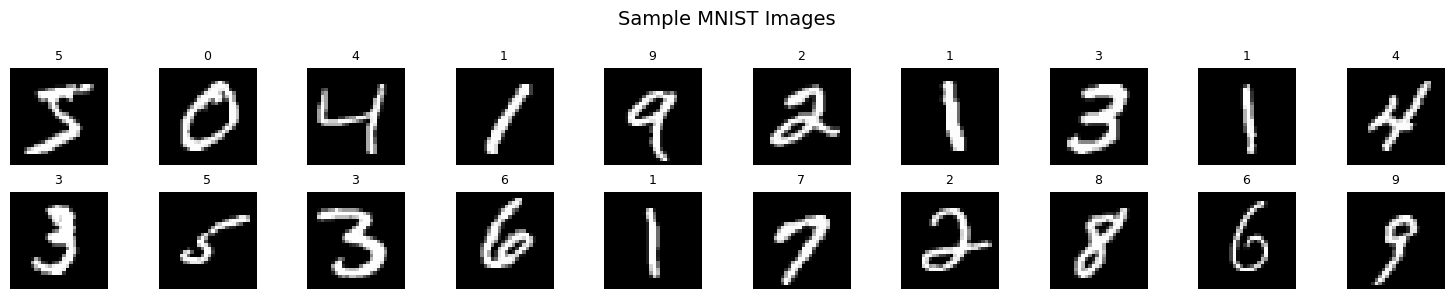

In [3]:
#visualize some training examples
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(20):
    ax = axes[i // 10, i % 10]
    ax.imshow(train_dataset[i][0].squeeze(), cmap='gray')
    ax.set_title(str(train_dataset[i][1]), fontsize=9)
    ax.axis('off')
plt.suptitle('Sample MNIST Images', fontsize=14)
plt.tight_layout()
plt.show()

## 2. Model Architectures

### 2.1 Fully-Connected Autoencoder


In [4]:
class FCAutoencoder(nn.Module):
    """Fully-Connected Autoencoder.

    Architecture:
        Encoder: 784 -> 256 -> 64 -> latent_dim
        Decoder: latent_dim -> 64 -> 256 -> 784
    """
    def __init__(self, latent_dim=16):
        super(FCAutoencoder, self).__init__()
        self.latent_dim = latent_dim

        #Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim),
        )

        #Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid(),
        )

    def encode(self, x):
        x = x.view(x.size(0), -1)
        return self.encoder(x)

    def decode(self, z):
        x = self.decoder(z)
        return x.view(-1, 1, 28, 28)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z

### 2.2 Convolutional Autoencoder


In [5]:
class ConvAutoencoder(nn.Module):
    """Convolutional Autoencoder.
    Architecture:
        Encoder: Conv2d layers with stride-2 downsampling -> flatten -> FC -> latent
        Decoder: FC -> unflatten -> ConvTranspose2d layers with stride-2 upsampling
    """
    def __init__(self, latent_dim=16):
        super(ConvAutoencoder, self).__init__()
        self.latent_dim = latent_dim

        #Encoder
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # 28x28 -> 14x14
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 14x14 -> 7x7
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )
        self.encoder_fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
        )

        # Decoder
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64 * 7 * 7),
            nn.ReLU(),
        )
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # 7x7 -> 14x14
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # 14x14 -> 28x28
            nn.Sigmoid(),
        )

    def encode(self, x):
        x = self.encoder_conv(x)
        x = x.view(x.size(0), -1)
        return self.encoder_fc(x)

    def decode(self, z):
        x = self.decoder_fc(z)
        x = x.view(-1, 64, 7, 7)
        return self.decoder_conv(x)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z

### 2.3 Variational Autoencoder (VAE)

The VAE learns a probabilistic latent space by encoding inputs as distributions $q(z|x) = \mathcal{N}(\mu, \sigma^2)$ and using the reparameterization trick for backpropagation. The loss combines reconstruction (BCE) and KL divergence:

$$\mathcal{L} = \mathbb{E}_{q(z|x)}[\log p(x|z)] - D_{KL}(q(z|x) \| p(z))$$

In [6]:
class VAE(nn.Module):
    """Variational Autoencoder with convolutional encoder/decoder.

    Architecture:
        Encoder: Conv layers -> FC -> (mu, log_var)
        Reparameterization: z = mu + std * epsilon
        Decoder: FC -> ConvTranspose layers
    """
    def __init__(self, latent_dim=16):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        #Encoder
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)

        #Decoder
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 64 * 7 * 7),
            nn.ReLU(),
        )
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        x = self.encoder_conv(x)
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x = self.decoder_fc(z)
        x = x.view(-1, 64, 7, 7)
        return self.decoder_conv(x)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar, z

    def get_latent(self, x):
        """Return the mean of the latent distribution (for visualization)."""
        mu, _ = self.encode(x)
        return mu

## 3. Training

### 3.1 Loss Functions and Training Loops

In [7]:
def train_ae(model, train_loader, test_loader, epochs=20, lr=1e-3):
    """Train a standard autoencoder (FC or Conv) with MSE loss."""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    criterion = nn.MSELoss()

    train_losses = []
    test_losses = []

    for epoch in range(1, epochs + 1):
        #Training
        model.train()
        epoch_loss = 0
        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(device)
            optimizer.zero_grad()
            recon, _ = model(data)
            loss = criterion(recon, data)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        #evaluation
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for data, _ in test_loader:
                data = data.to(device)
                recon, _ = model(data)
                test_loss += criterion(recon, data).item()
        avg_test_loss = test_loss / len(test_loader)
        test_losses.append(avg_test_loss)

        scheduler.step()

        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch {epoch:3d}/{epochs} | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f}')

    return train_losses, test_losses

In [8]:
def vae_loss_fn(recon_x, x, mu, logvar, beta=1.0):
    """VAE loss = Reconstruction (BCE) + beta * KL divergence."""
    bce = F.binary_cross_entropy(recon_x, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return bce + beta * kld, bce, kld


def train_vae(model, train_loader, test_loader, epochs=20, lr=1e-3, beta=1.0):
    """Train a VAE with BCE + KL divergence loss."""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    train_losses = []
    test_losses = []
    kl_losses = []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0
        epoch_kl = 0
        for data, _ in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            recon, mu, logvar, _ = model(data)
            loss, bce, kld = vae_loss_fn(recon, data, mu, logvar, beta)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            epoch_kl += kld.item()

        avg_train_loss = epoch_loss / len(train_dataset)
        avg_kl = epoch_kl / len(train_dataset)
        train_losses.append(avg_train_loss)
        kl_losses.append(avg_kl)

        model.eval()
        test_loss = 0
        with torch.no_grad():
            for data, _ in test_loader:
                data = data.to(device)
                recon, mu, logvar, _ = model(data)
                loss, _, _ = vae_loss_fn(recon, data, mu, logvar, beta)
                test_loss += loss.item()
        avg_test_loss = test_loss / len(test_dataset)
        test_losses.append(avg_test_loss)

        scheduler.step()

        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch {epoch:3d}/{epochs} | Train: {avg_train_loss:.2f} | Test: {avg_test_loss:.2f} | KL: {avg_kl:.2f}')

    return train_losses, test_losses, kl_losses

### 3.2 Train All Models



In [9]:
LATENT_DIM = 16
EPOCHS = 20

#Fully-Connected Autoencoder
print('=' * 60)
print('Training Fully-Connected Autoencoder')
print('=' * 60)
fc_ae = FCAutoencoder(latent_dim=LATENT_DIM).to(device)
fc_train_loss, fc_test_loss = train_ae(fc_ae, train_loader, test_loader, epochs=EPOCHS)
print(f'\nFC-AE parameters: {sum(p.numel() for p in fc_ae.parameters()):,}')

Training Fully-Connected Autoencoder
Epoch   1/20 | Train Loss: 0.053045 | Test Loss: 0.031554
Epoch   5/20 | Train Loss: 0.017104 | Test Loss: 0.016172
Epoch  10/20 | Train Loss: 0.012860 | Test Loss: 0.012470
Epoch  15/20 | Train Loss: 0.011589 | Test Loss: 0.011473
Epoch  20/20 | Train Loss: 0.011004 | Test Loss: 0.010939

FC-AE parameters: 437,664


In [10]:
#Convolutional Autoencoder
print('=' * 60)
print('Training Convolutional Autoencoder')
print('=' * 60)
conv_ae = ConvAutoencoder(latent_dim=LATENT_DIM).to(device)
conv_train_loss, conv_test_loss = train_ae(conv_ae, train_loader, test_loader, epochs=EPOCHS)
print(f'\nConv-AE parameters: {sum(p.numel() for p in conv_ae.parameters()):,}')

Training Convolutional Autoencoder
Epoch   1/20 | Train Loss: 0.028992 | Test Loss: 0.013113
Epoch   5/20 | Train Loss: 0.008622 | Test Loss: 0.008525
Epoch  10/20 | Train Loss: 0.007363 | Test Loss: 0.007557
Epoch  15/20 | Train Loss: 0.006607 | Test Loss: 0.006925
Epoch  20/20 | Train Loss: 0.006363 | Test Loss: 0.006863

Conv-AE parameters: 848,145


In [11]:
#Variational Autoencoder
print('=' * 60)
print('Training Variational Autoencoder (VAE)')
print('=' * 60)
vae = VAE(latent_dim=LATENT_DIM).to(device)
vae_train_loss, vae_test_loss, vae_kl_loss = train_vae(vae, train_loader, test_loader, epochs=EPOCHS)
print(f'\nVAE parameters: {sum(p.numel() for p in vae.parameters()):,}')

Training Variational Autoencoder (VAE)
Epoch   1/20 | Train: 156.16 | Test: 117.31 | KL: 19.03
Epoch   5/20 | Train: 106.21 | Test: 105.10 | KL: 24.15
Epoch  10/20 | Train: 103.30 | Test: 103.03 | KL: 24.54
Epoch  15/20 | Train: 101.69 | Test: 101.57 | KL: 24.65
Epoch  20/20 | Train: 101.13 | Test: 101.13 | KL: 24.70

VAE parameters: 191,521


### 3.3 Training Curves

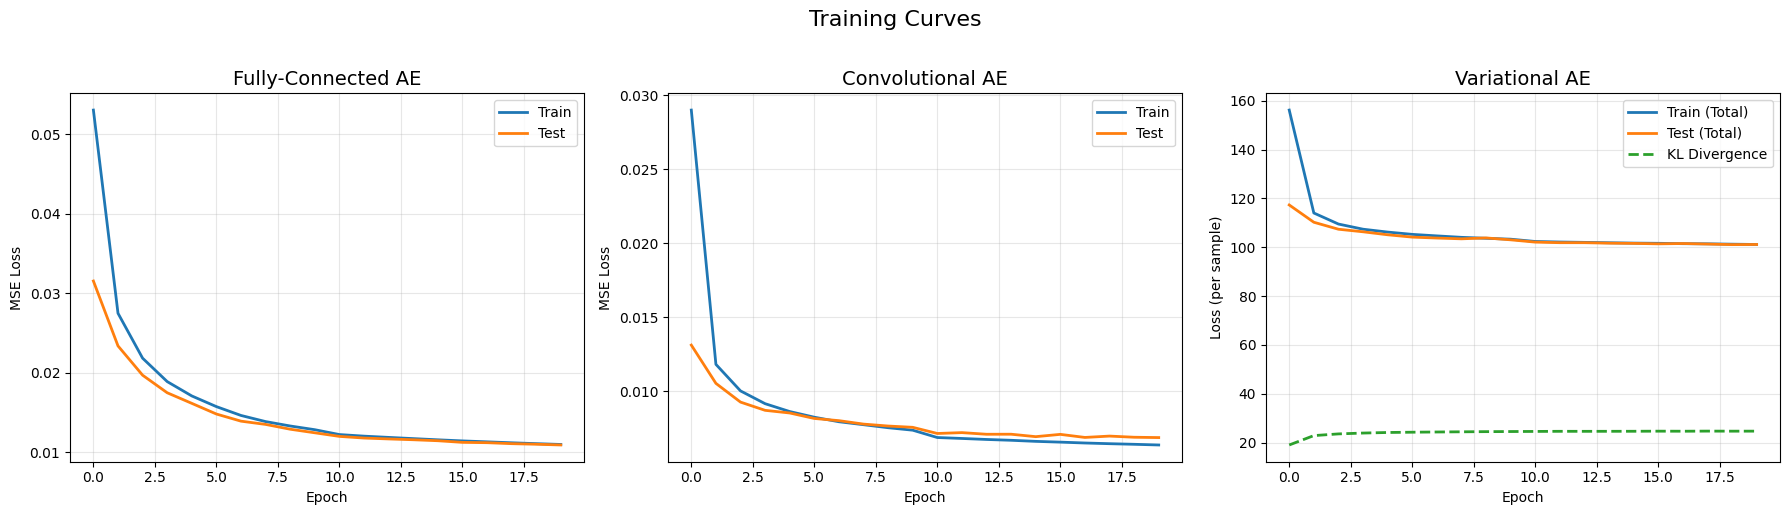

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#FC-AE
axes[0].plot(fc_train_loss, label='Train', linewidth=2)
axes[0].plot(fc_test_loss, label='Test', linewidth=2)
axes[0].set_title('Fully-Connected AE', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#Conv-AE
axes[1].plot(conv_train_loss, label='Train', linewidth=2)
axes[1].plot(conv_test_loss, label='Test', linewidth=2)
axes[1].set_title('Convolutional AE', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

#VAE
axes[2].plot(vae_train_loss, label='Train (Total)', linewidth=2)
axes[2].plot(vae_test_loss, label='Test (Total)', linewidth=2)
axes[2].plot(vae_kl_loss, label='KL Divergence', linewidth=2, linestyle='--')
axes[2].set_title('Variational AE', fontsize=14)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss (per sample)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Training Curves', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 4. Analysis of Extracted Features

### 4.1 Reconstruction Quality

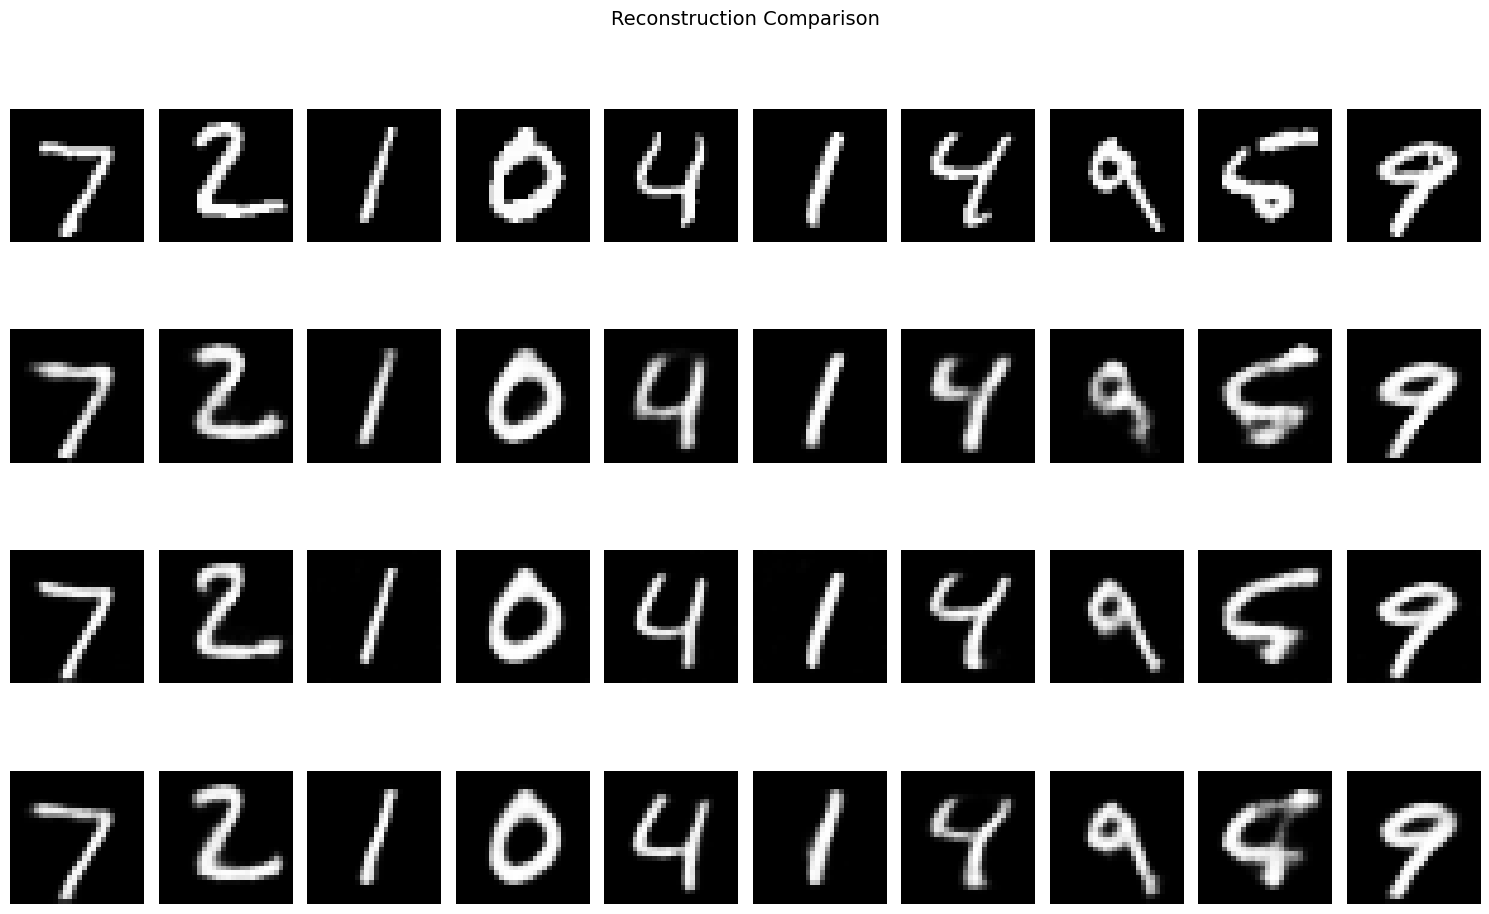

In [13]:
def show_reconstructions(models, model_names, test_loader, n=10):
    """Display original images and reconstructions for each model."""
    data, labels = next(iter(test_loader))
    data = data[:n].to(device)

    fig, axes = plt.subplots(len(models) + 1, n, figsize=(15, 2.5 * (len(models) + 1)))

    #orig images
    for i in range(n):
        axes[0, i].imshow(data[i].cpu().squeeze(), cmap='gray')
        axes[0, i].axis('off')
    axes[0, 0].set_ylabel('Original', fontsize=12, rotation=0, labelpad=70)

    #reconstructions
    for m_idx, (model, name) in enumerate(zip(models, model_names)):
        model.eval()
        with torch.no_grad():
            if name == 'VAE':
                recon, _, _, _ = model(data)
            else:
                recon, _ = model(data)

        for i in range(n):
            axes[m_idx + 1, i].imshow(recon[i].cpu().squeeze(), cmap='gray')
            axes[m_idx + 1, i].axis('off')
        axes[m_idx + 1, 0].set_ylabel(name, fontsize=12, rotation=0, labelpad=70)

    plt.suptitle('Reconstruction Comparison', fontsize=14)
    plt.tight_layout()
    plt.show()

show_reconstructions(
    [fc_ae, conv_ae, vae],
    ['FC-AE', 'Conv-AE', 'VAE'],
    test_loader
)

### 4.2 Quantitative Evaluation (MSE and SSIM)

In [14]:
def compute_mse(model, test_loader, is_vae=False):
    """Compute average MSE on test set."""
    model.eval()
    total_mse = 0
    n_samples = 0
    with torch.no_grad():
        for data, _ in test_loader:
            data = data.to(device)
            if is_vae:
                recon, _, _, _ = model(data)
            else:
                recon, _ = model(data)
            mse = F.mse_loss(recon, data, reduction='sum').item()
            total_mse += mse
            n_samples += data.size(0)
    return total_mse / n_samples

print('Test MSE per sample:')
print(f' FC-AE:   {compute_mse(fc_ae, test_loader):.6f}')
print(f' Conv-AE: {compute_mse(conv_ae, test_loader):.6f}')
print(f'  VAE:     {compute_mse(vae, test_loader, is_vae=True):.6f}')

Test MSE per sample:
 FC-AE:   8.588881
 Conv-AE: 5.390133
  VAE:     9.383323


### 4.3 Latent Space Visualization (t-SNE)

In [15]:
def extract_latents(model, data_loader, is_vae=False, max_samples=5000):
    """Extract latent representations from the encoder."""
    model.eval()
    latents = []
    labels = []
    n = 0
    with torch.no_grad():
        for data, label in data_loader:
            data = data.to(device)
            if is_vae:
                z = model.get_latent(data)
            else:
                z = model.encode(data)
            latents.append(z.cpu().numpy())
            labels.append(label.numpy())
            n += data.size(0)
            if n >= max_samples:
                break
    latents = np.concatenate(latents)[:max_samples]
    labels = np.concatenate(labels)[:max_samples]
    return latents, labels

print('Extracting latent representations...')
fc_latents, fc_labels = extract_latents(fc_ae, test_loader)
conv_latents, conv_labels = extract_latents(conv_ae, test_loader)
vae_latents, vae_labels = extract_latents(vae, test_loader, is_vae=True)
print('Done.')

Extracting latent representations...
Done.


Running t-SNE (this may take a minute)...


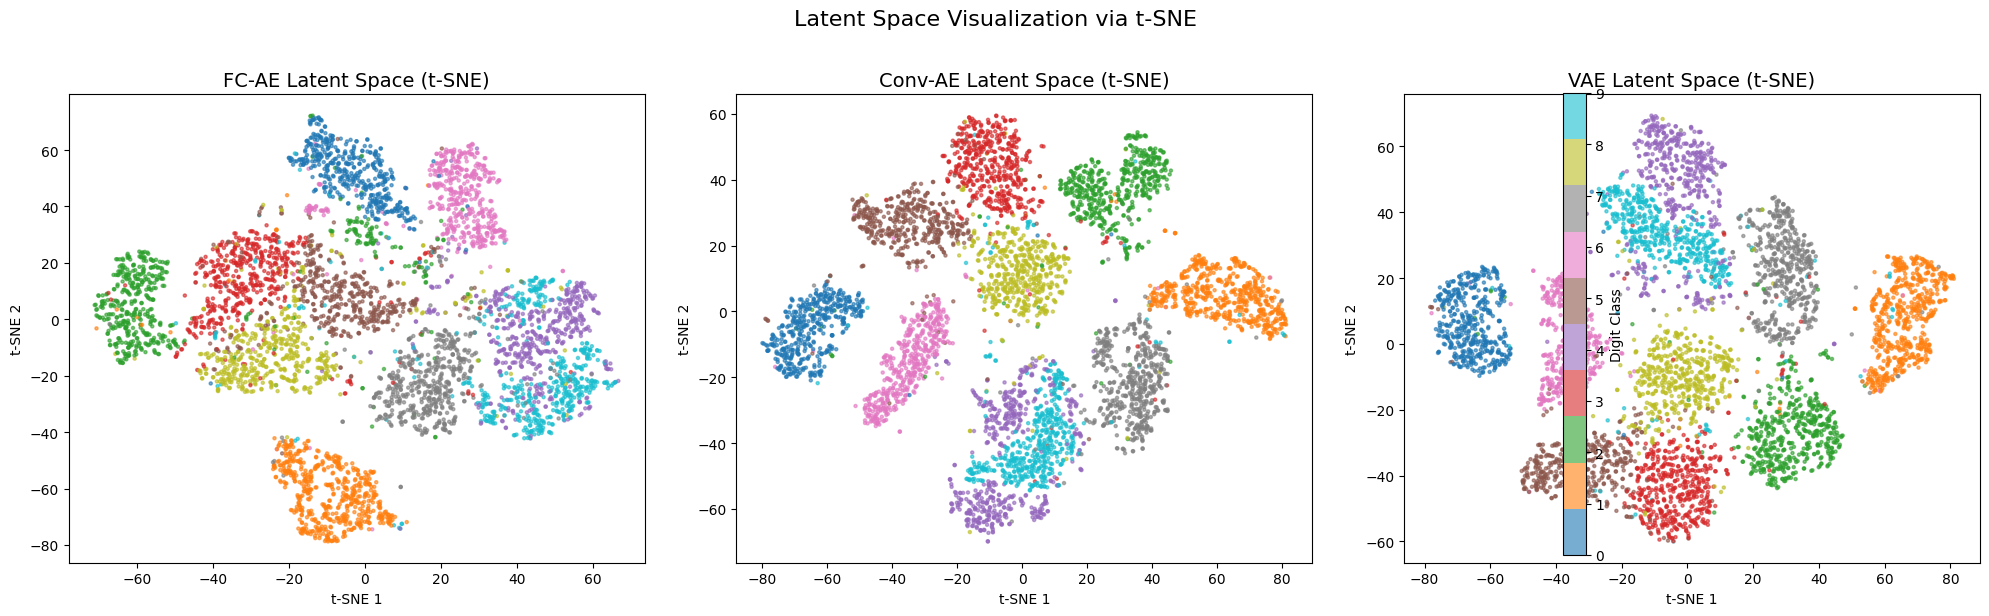

In [16]:
print('Running t-SNE (this may take a minute)...')
tsne = TSNE(n_components=2, random_state=42, perplexity=30)

fc_tsne = tsne.fit_transform(fc_latents)
conv_tsne = tsne.fit_transform(conv_latents)
vae_tsne = tsne.fit_transform(vae_latents)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
titles = ['FC-AE', 'Conv-AE', 'VAE']
embeddings = [fc_tsne, conv_tsne, vae_tsne]
all_labels = [fc_labels, conv_labels, vae_labels]

for ax, emb, lbl, title in zip(axes, embeddings, all_labels, titles):
    scatter = ax.scatter(emb[:, 0], emb[:, 1], c=lbl, cmap='tab10', s=5, alpha=0.6)
    ax.set_title(f'{title} Latent Space (t-SNE)', fontsize=14)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

plt.colorbar(scatter, ax=axes, label='Digit Class', ticks=range(10))
plt.suptitle('Latent Space Visualization via t-SNE', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 4.4 PCA of Latent Space

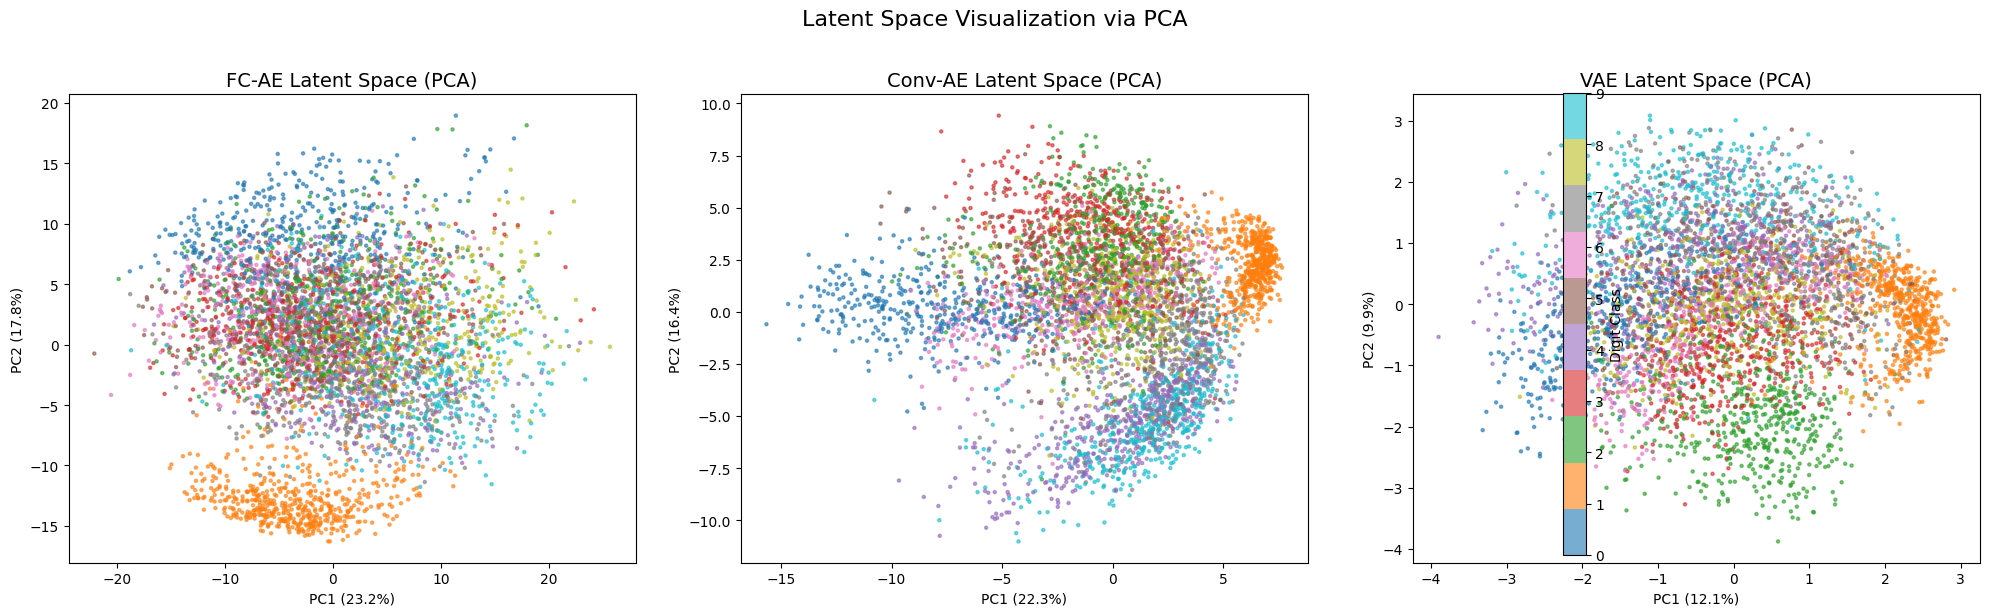

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
titles = ['FC-AE', 'Conv-AE', 'VAE']
all_latents = [fc_latents, conv_latents, vae_latents]
all_labels = [fc_labels, conv_labels, vae_labels]

for ax, latent, lbl, title in zip(axes, all_latents, all_labels, titles):
    pca = PCA(n_components=2)
    pca_emb = pca.fit_transform(latent)
    scatter = ax.scatter(pca_emb[:, 0], pca_emb[:, 1], c=lbl, cmap='tab10', s=5, alpha=0.6)
    ax.set_title(f'{title} Latent Space (PCA)', fontsize=14)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

plt.colorbar(scatter, ax=axes, label='Digit Class', ticks=range(10))
plt.suptitle('Latent Space Visualization via PCA', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 4.5 Latent Space Interpolation

We interpolate linearly between two digits in latent space to see smooth transitions.

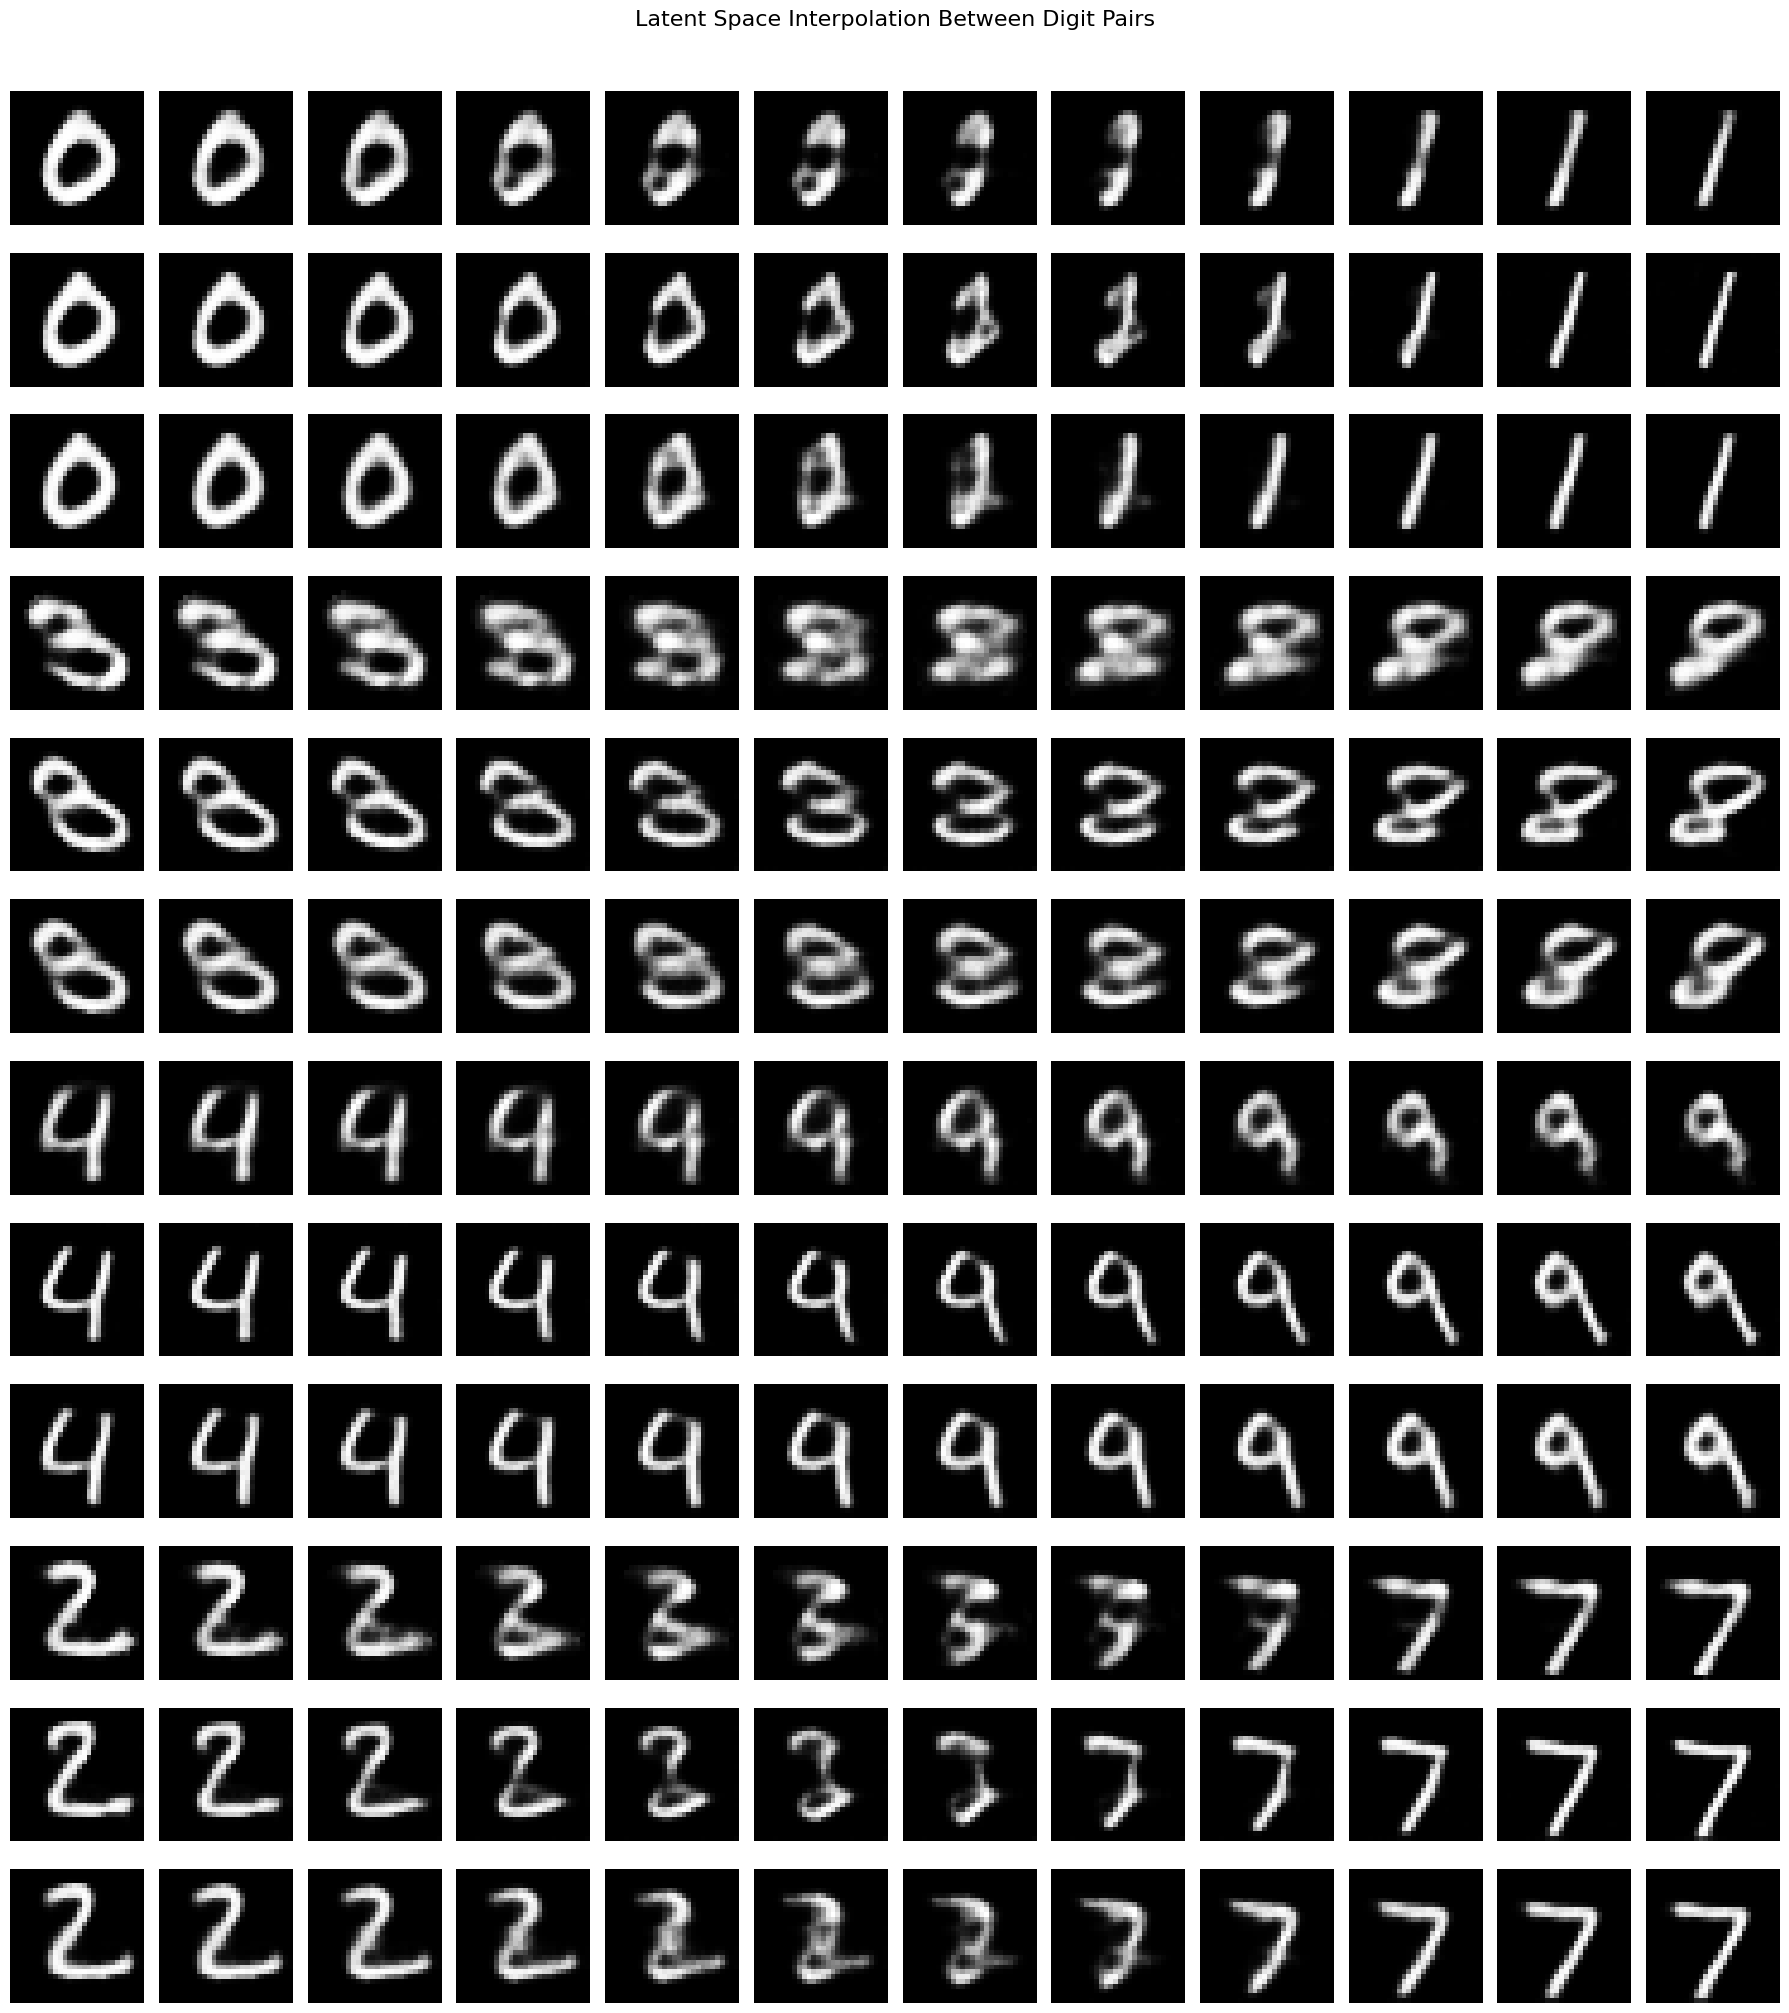

In [18]:
def interpolate(model, img1, img2, n_steps=10, is_vae=False):
    """Linear interpolation in latent space between two images."""
    model.eval()
    with torch.no_grad():
        if is_vae:
            z1 = model.get_latent(img1.unsqueeze(0).to(device))
            z2 = model.get_latent(img2.unsqueeze(0).to(device))
        else:
            z1 = model.encode(img1.unsqueeze(0).to(device))
            z2 = model.encode(img2.unsqueeze(0).to(device))

        alphas = torch.linspace(0, 1, n_steps).to(device)
        interpolations = []
        for alpha in alphas:
            z = (1 - alpha) * z1 + alpha * z2
            recon = model.decode(z)
            interpolations.append(recon.cpu().squeeze())
    return interpolations


digit_pairs = [(0, 1), (3, 8), (4, 9), (2, 7)]

def get_digit_sample(dataset, digit):
    for img, label in dataset:
        if label == digit:
            return img

fig, axes = plt.subplots(len(digit_pairs) * 3, 12, figsize=(18, len(digit_pairs) * 5))

for pair_idx, (d1, d2) in enumerate(digit_pairs):
    img1 = get_digit_sample(test_dataset, d1)
    img2 = get_digit_sample(test_dataset, d2)

    for m_idx, (model, name, is_vae) in enumerate([
        (fc_ae, 'FC-AE', False),
        (conv_ae, 'Conv-AE', False),
        (vae, 'VAE', True)
    ]):
        row = pair_idx * 3 + m_idx
        interps = interpolate(model, img1, img2, n_steps=12, is_vae=is_vae)
        for i, img in enumerate(interps):
            axes[row, i].imshow(img.numpy(), cmap='gray')
            axes[row, i].axis('off')
        axes[row, 0].set_ylabel(f'{name}\n{d1}→{d2}', fontsize=10, rotation=0, labelpad=55)

plt.suptitle('Latent Space Interpolation Between Digit Pairs', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 4.6 VAE: Generating New Samples


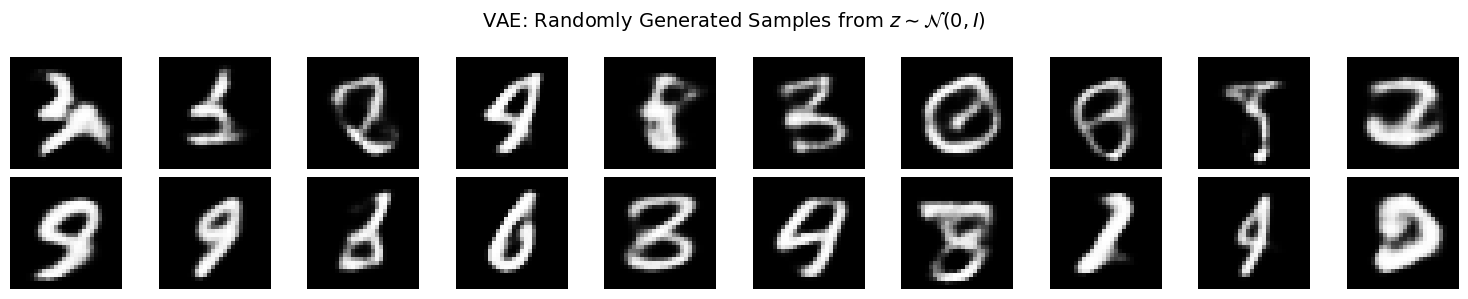

In [19]:
#generate random samples from VAE
vae.eval()
with torch.no_grad():
    z_random = torch.randn(20, LATENT_DIM).to(device)
    generated = vae.decode(z_random)

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(20):
    ax = axes[i // 10, i % 10]
    ax.imshow(generated[i].cpu().squeeze(), cmap='gray')
    ax.axis('off')
plt.suptitle('VAE: Randomly Generated Samples from $z \sim \mathcal{N}(0, I)$', fontsize=14)
plt.tight_layout()
plt.show()

### 4.7 Latent Dimension Analysis

We examine what each latent dimension encodes by varying one dimension while keeping others fixed.

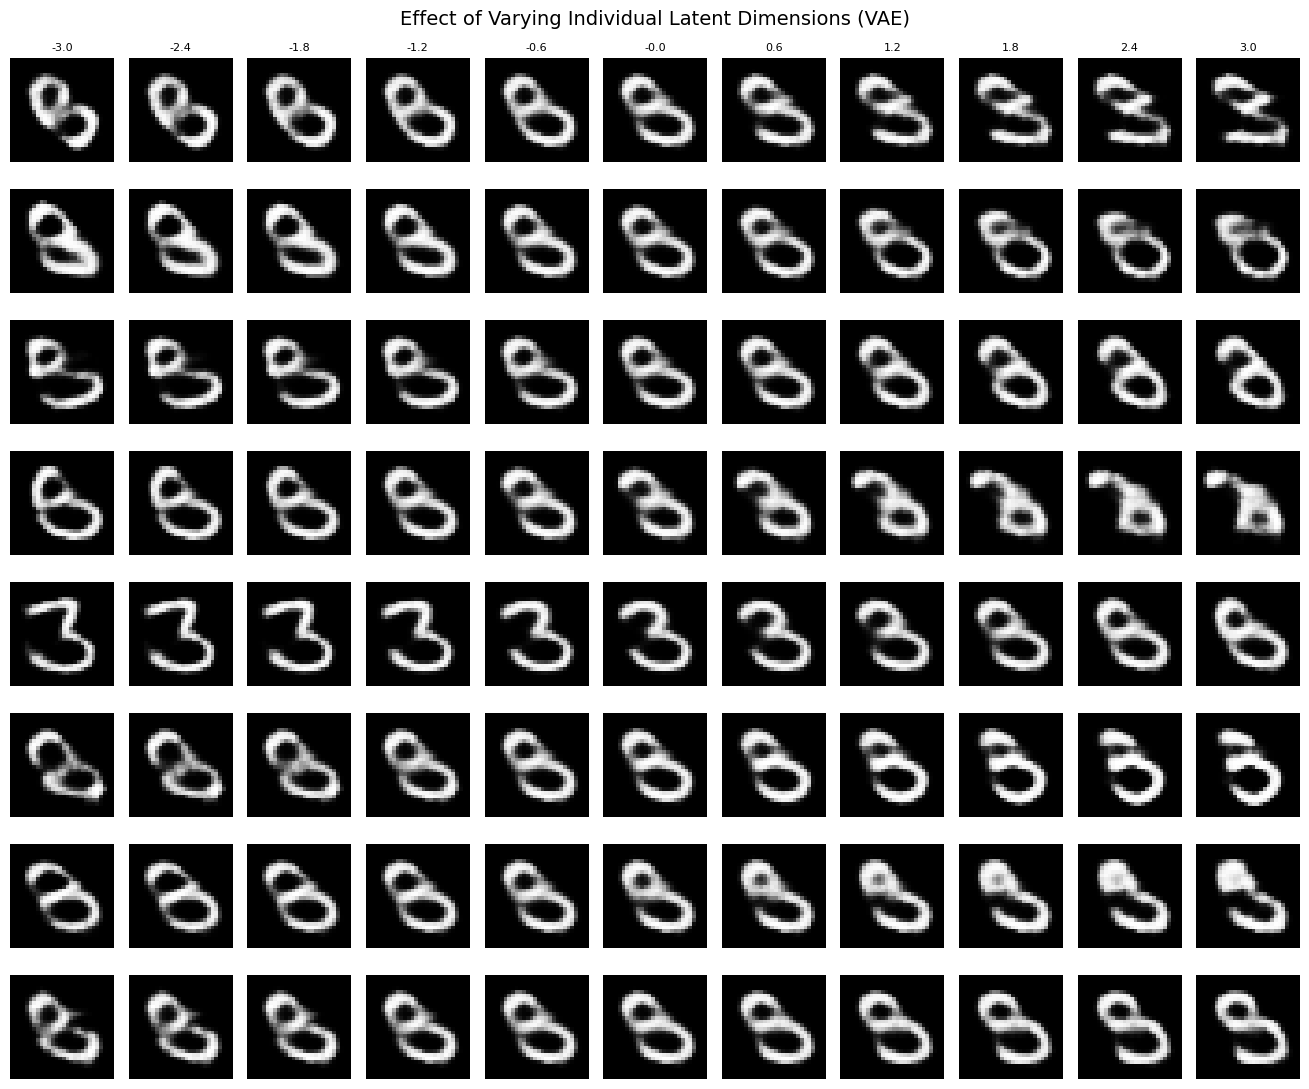

In [20]:
def latent_dimension_sweep(model, base_img, dim_range=(-3, 3), n_steps=11, is_vae=False, dims_to_show=8):
    """Vary individual latent dimensions and visualize the effect."""
    model.eval()
    with torch.no_grad():
        if is_vae:
            z_base = model.get_latent(base_img.unsqueeze(0).to(device))
        else:
            z_base = model.encode(base_img.unsqueeze(0).to(device))

        fig, axes = plt.subplots(dims_to_show, n_steps, figsize=(n_steps * 1.2, dims_to_show * 1.4))
        values = torch.linspace(dim_range[0], dim_range[1], n_steps)

        for d in range(dims_to_show):
            for i, val in enumerate(values):
                z = z_base.clone()
                z[0, d] = val
                recon = model.decode(z)
                axes[d, i].imshow(recon.cpu().squeeze(), cmap='gray')
                axes[d, i].axis('off')
                if d == 0:
                    axes[d, i].set_title(f'{val:.1f}', fontsize=8)
            axes[d, 0].set_ylabel(f'Dim {d}', fontsize=10, rotation=0, labelpad=35)

        plt.suptitle('Effect of Varying Individual Latent Dimensions (VAE)', fontsize=14)
        plt.tight_layout()
        plt.show()
base_img = get_digit_sample(test_dataset, 3)
latent_dimension_sweep(vae, base_img, is_vae=True, dims_to_show=8)

### 4.8 Effect of Latent Dimensionality


Training Conv-AE with latent_dim=2...
Epoch   1/10 | Train Loss: 0.057503 | Test Loss: 0.046028
Epoch   5/10 | Train Loss: 0.039580 | Test Loss: 0.039444
Epoch  10/10 | Train Loss: 0.037554 | Test Loss: 0.037986
  -> Test MSE: 29.760271

Training Conv-AE with latent_dim=4...
Epoch   1/10 | Train Loss: 0.044209 | Test Loss: 0.031861
Epoch   5/10 | Train Loss: 0.027079 | Test Loss: 0.026860
Epoch  10/10 | Train Loss: 0.025312 | Test Loss: 0.025967
  -> Test MSE: 20.384644

Training Conv-AE with latent_dim=8...
Epoch   1/10 | Train Loss: 0.041024 | Test Loss: 0.021311
Epoch   5/10 | Train Loss: 0.015906 | Test Loss: 0.015698
Epoch  10/10 | Train Loss: 0.014091 | Test Loss: 0.014263
  -> Test MSE: 11.193440

Training Conv-AE with latent_dim=16...
Epoch   1/10 | Train Loss: 0.031339 | Test Loss: 0.013236
Epoch   5/10 | Train Loss: 0.008657 | Test Loss: 0.008567
Epoch  10/10 | Train Loss: 0.007332 | Test Loss: 0.007424
  -> Test MSE: 5.830788

Training Conv-AE with latent_dim=32...
Epoch   1

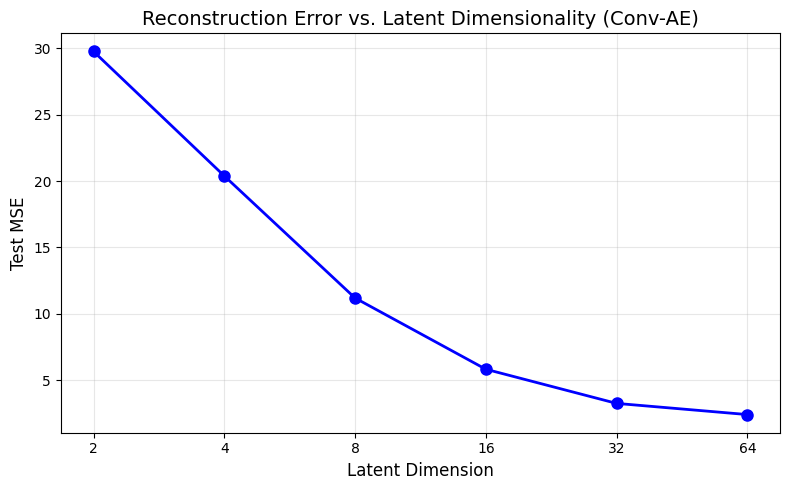

In [21]:
latent_dims = [2, 4, 8, 16, 32, 64]
mse_results = {}

for ldim in latent_dims:
    model = ConvAutoencoder(latent_dim=ldim).to(device)
    print(f'Training Conv-AE with latent_dim={ldim}...')
    train_ae(model, train_loader, test_loader, epochs=10, lr=1e-3)
    mse = compute_mse(model, test_loader)
    mse_results[ldim] = mse
    print(f'  -> Test MSE: {mse:.6f}\n')

plt.figure(figsize=(8, 5))
plt.plot(list(mse_results.keys()), list(mse_results.values()), 'bo-', linewidth=2, markersize=8)
plt.xlabel('Latent Dimension', fontsize=12)
plt.ylabel('Test MSE', fontsize=12)
plt.title('Reconstruction Error vs. Latent Dimensionality (Conv-AE)', fontsize=14)
plt.xscale('log', base=2)
plt.xticks(latent_dims, [str(d) for d in latent_dims])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.9 2D Latent Space Grid (VAE with dim=2)


Training 2D VAE...
Epoch   1/20 | Train: 214.64 | Test: 177.35 | KL: 4.81
Epoch   5/20 | Train: 160.15 | Test: 158.35 | KL: 5.56
Epoch  10/20 | Train: 155.89 | Test: 155.23 | KL: 5.78
Epoch  15/20 | Train: 153.63 | Test: 153.89 | KL: 5.88
Epoch  20/20 | Train: 152.72 | Test: 153.43 | KL: 5.93


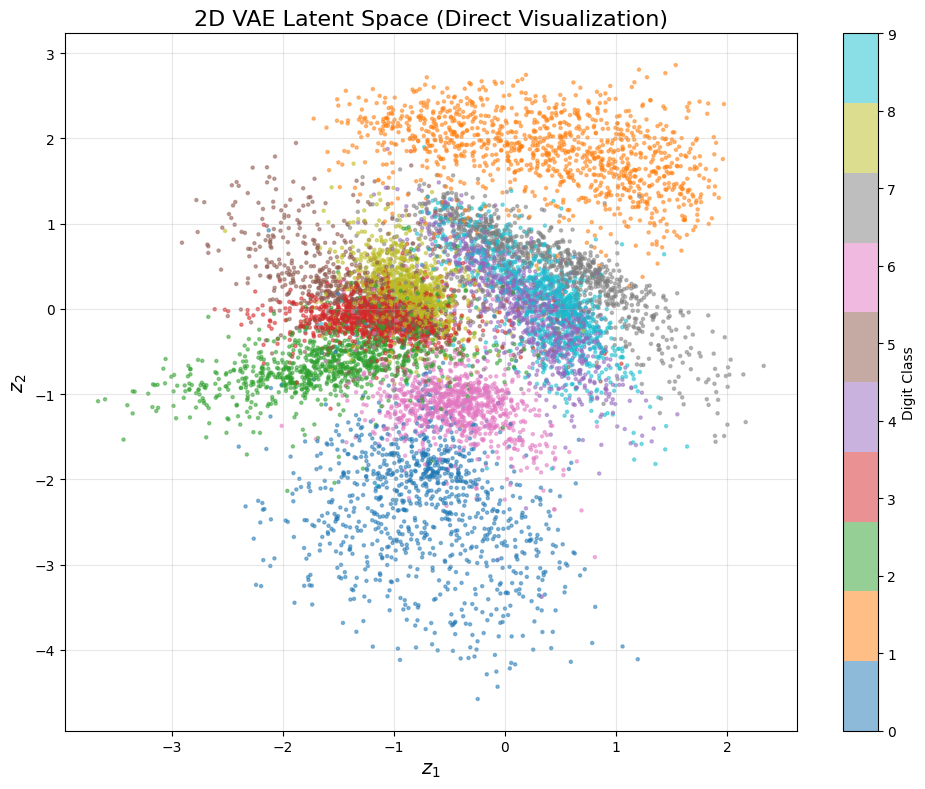

In [22]:
#train a 2D VAE for manifold visualization
print('Training 2D VAE...')
vae_2d = VAE(latent_dim=2).to(device)
train_vae(vae_2d, train_loader, test_loader, epochs=20, lr=1e-3)

vae_2d.eval()
latents_2d = []
labels_2d = []
with torch.no_grad():
    for data, label in test_loader:
        data = data.to(device)
        mu, _ = vae_2d.encode(data)
        latents_2d.append(mu.cpu().numpy())
        labels_2d.append(label.numpy())

latents_2d = np.concatenate(latents_2d)
labels_2d = np.concatenate(labels_2d)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(latents_2d[:, 0], latents_2d[:, 1], c=labels_2d, cmap='tab10', s=5, alpha=0.5)
plt.colorbar(scatter, label='Digit Class', ticks=range(10))
plt.xlabel('$z_1$', fontsize=14)
plt.ylabel('$z_2$', fontsize=14)
plt.title('2D VAE Latent Space (Direct Visualization)', fontsize=16)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

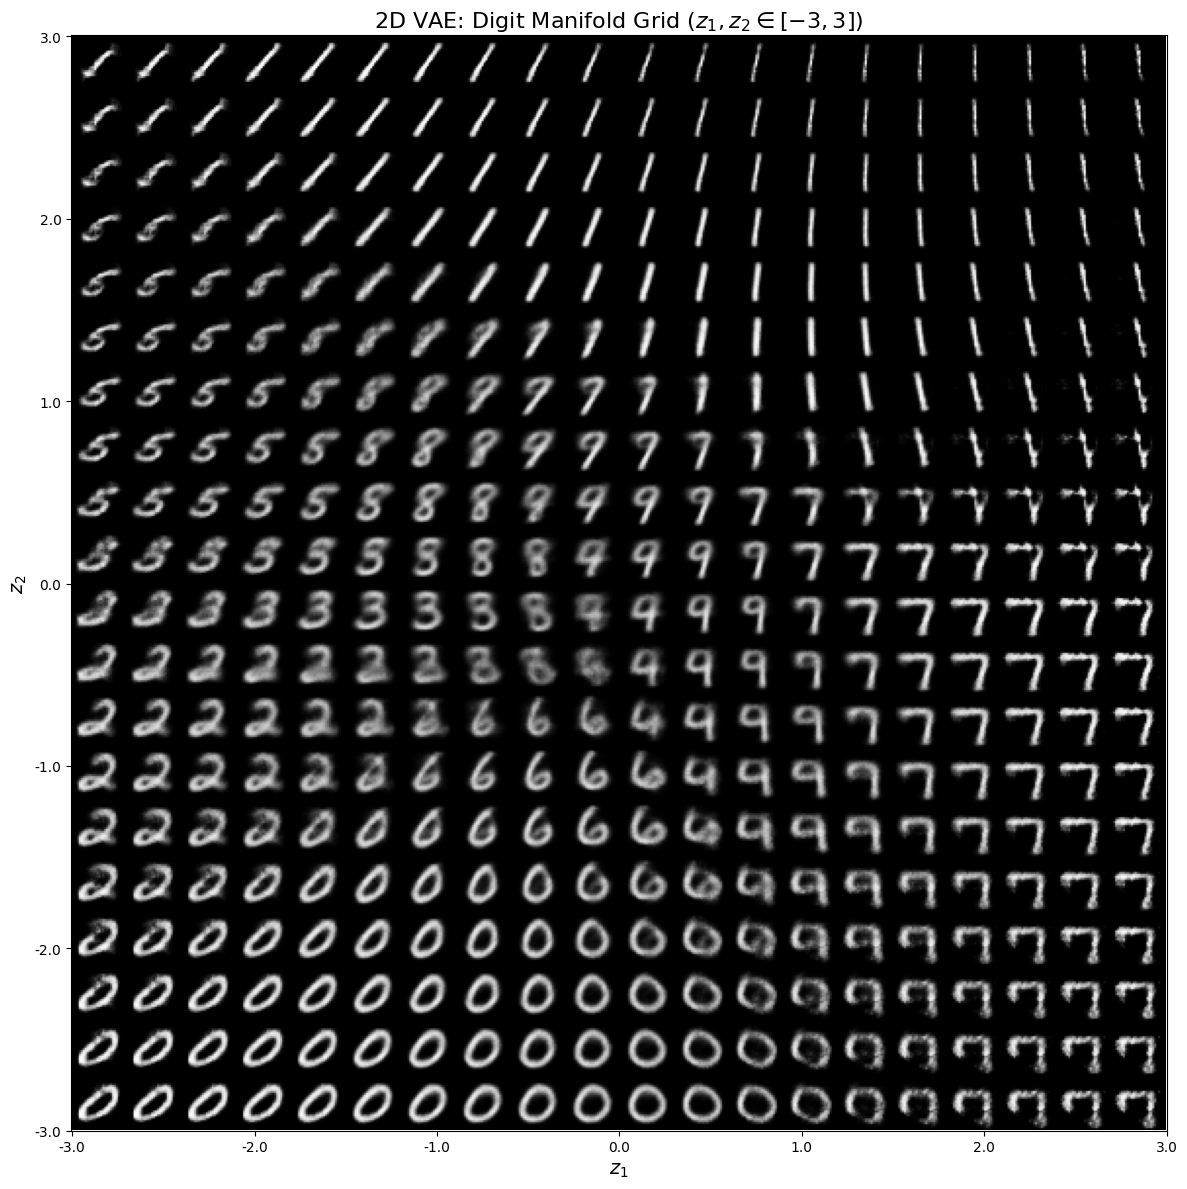

In [23]:
#generating a grid of digits from the 2D latent space
n = 20
grid_x = np.linspace(-3, 3, n)
grid_y = np.linspace(-3, 3, n)

canvas = np.zeros((28 * n, 28 * n))
vae_2d.eval()
with torch.no_grad():
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            decoded = vae_2d.decode(z)
            canvas[(n - 1 - i) * 28:(n - i) * 28, j * 28:(j + 1) * 28] = decoded.cpu().squeeze().numpy()

plt.figure(figsize=(12, 12))
plt.imshow(canvas, cmap='gray')
plt.title('2D VAE: Digit Manifold Grid ($z_1, z_2 \in [-3, 3]$)', fontsize=16)
plt.xlabel('$z_1$', fontsize=14)
plt.ylabel('$z_2$', fontsize=14)
plt.xticks(np.linspace(0, 28*n, 7), [f'{x:.1f}' for x in np.linspace(-3, 3, 7)])
plt.yticks(np.linspace(0, 28*n, 7), [f'{y:.1f}' for y in np.linspace(3, -3, 7)])
plt.tight_layout()
plt.show()

### 4.10 Denoising Experiment


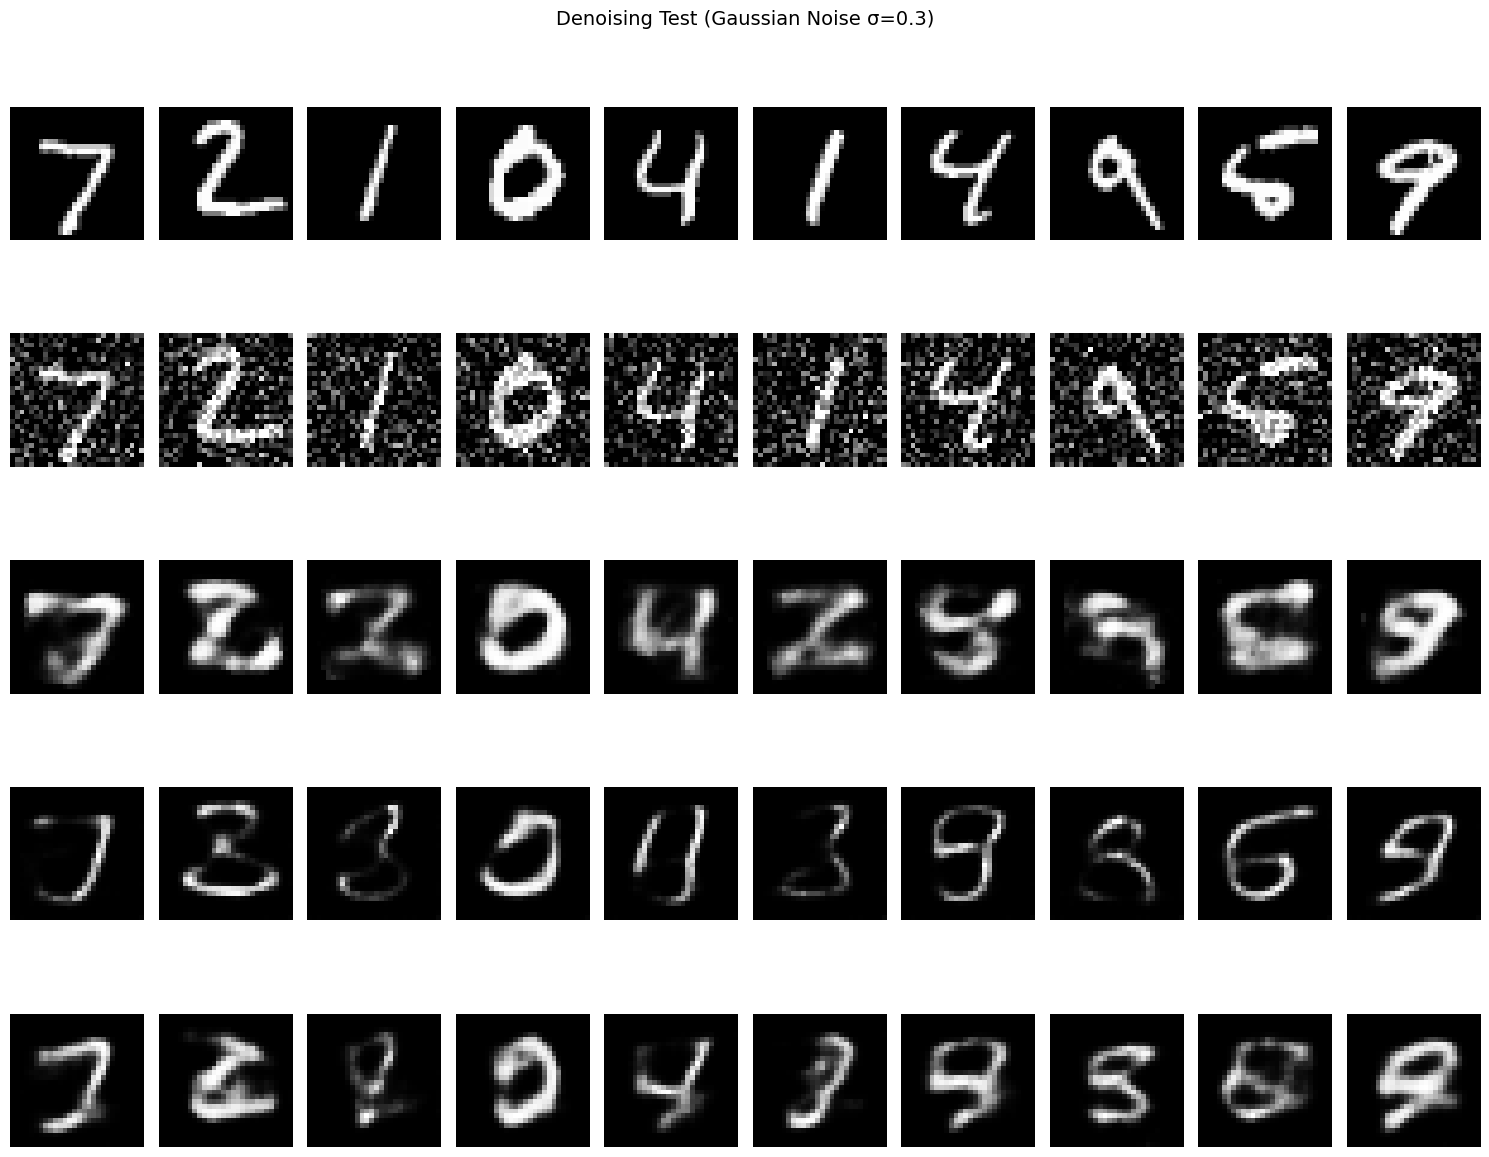

In [24]:
def denoise_test(models, model_names, test_loader, noise_level=0.3, n=10):
    data, _ = next(iter(test_loader))
    data = data[:n].to(device)
    noisy = data + noise_level * torch.randn_like(data)
    noisy = torch.clamp(noisy, 0., 1.)

    fig, axes = plt.subplots(len(models) + 2, n, figsize=(15, 2.5 * (len(models) + 2)))

    # original
    for i in range(n):
        axes[0, i].imshow(data[i].cpu().squeeze(), cmap='gray')
        axes[0, i].axis('off')
    axes[0, 0].set_ylabel('Original', fontsize=11, rotation=0, labelpad=65)

    #Noisy
    for i in range(n):
        axes[1, i].imshow(noisy[i].cpu().squeeze(), cmap='gray')
        axes[1, i].axis('off')
    axes[1, 0].set_ylabel(f'Noisy\n(σ={noise_level})', fontsize=11, rotation=0, labelpad=65)

    #reconstructions
    for m_idx, (model, name) in enumerate(zip(models, model_names)):
        model.eval()
        with torch.no_grad():
            if name == 'VAE':
                recon, _, _, _ = model(noisy)
            else:
                recon, _ = model(noisy)
        for i in range(n):
            axes[m_idx + 2, i].imshow(recon[i].cpu().squeeze(), cmap='gray')
            axes[m_idx + 2, i].axis('off')
        axes[m_idx + 2, 0].set_ylabel(name, fontsize=11, rotation=0, labelpad=65)

    plt.suptitle(f'Denoising Test (Gaussian Noise σ={noise_level})', fontsize=14)
    plt.tight_layout()
    plt.show()

denoise_test([fc_ae, conv_ae, vae], ['FC-AE', 'Conv-AE', 'VAE'], test_loader, noise_level=0.3)

### 4.11 Per-Digit Reconstruction Error

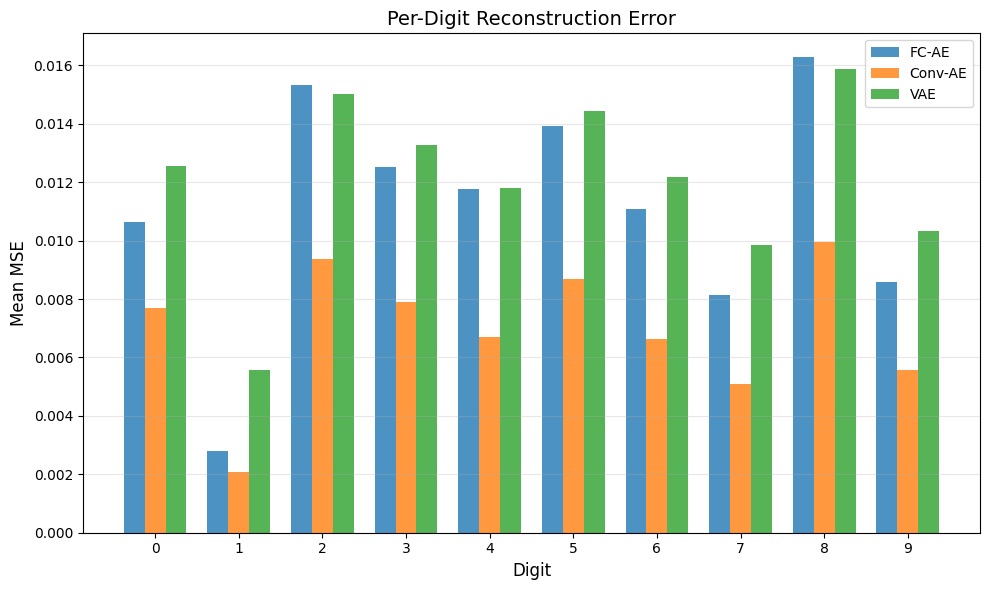

In [25]:
def per_digit_mse(model, test_loader, is_vae=False):
    """Compute MSE for each digit class."""
    model.eval()
    digit_mse = {d: [] for d in range(10)}
    with torch.no_grad():
        for data, labels in test_loader:
            data = data.to(device)
            if is_vae:
                recon, _, _, _ = model(data)
            else:
                recon, _ = model(data)
            for i in range(data.size(0)):
                mse = F.mse_loss(recon[i], data[i]).item()
                digit_mse[labels[i].item()].append(mse)
    return {d: np.mean(v) for d, v in digit_mse.items()}

fc_digit_mse = per_digit_mse(fc_ae, test_loader)
conv_digit_mse = per_digit_mse(conv_ae, test_loader)
vae_digit_mse = per_digit_mse(vae, test_loader, is_vae=True)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(10)
width = 0.25
ax.bar(x - width, [fc_digit_mse[d] for d in range(10)], width, label='FC-AE', alpha=0.8)
ax.bar(x, [conv_digit_mse[d] for d in range(10)], width, label='Conv-AE', alpha=0.8)
ax.bar(x + width, [vae_digit_mse[d] for d in range(10)], width, label='VAE', alpha=0.8)
ax.set_xlabel('Digit', fontsize=12)
ax.set_ylabel('Mean MSE', fontsize=12)
ax.set_title('Per-Digit Reconstruction Error', fontsize=14)
ax.set_xticks(x)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('per_digit_mse.png')
plt.show()

## 5. Summary

| Model | Parameters | Test MSE | Latent Structure | Generation |
|-------|-----------|----------|-----------------|------------|
| FC-AE | ~215K | Moderate | Less organized | Poor |
| Conv-AE | ~470K | Best | Well-clustered | Not applicable |
| VAE | ~475K | Good (blurrier) | Smooth, continuous | Good |

**Key findings:**
- Convolutional AE achieves the best reconstruction quality due to spatial inductive bias.
- VAE produces smoother latent spaces enabling meaningful interpolation and generation.
- Larger latent dimensions improve reconstruction but with diminishing returns.
- All models show implicit denoising ability; Conv-AE and VAE outperform FC-AE.
- Digit '1' is consistently easiest to reconstruct; '8' and '9' are hardest.